In [1]:
import requests
import pandas as pd
from dateutil import parser, rrule
from datetime import datetime, time, date
import time

In [3]:
data = pd.read_csv("Weather.csv")


In [4]:
print(data)

     Unnamed: 0  YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG  \
0             0  1901  17.99  19.43  23.49  26.41  28.28  28.60  27.49  26.98   
1             1  1902  19.00  20.39  24.10  26.54  28.68  28.44  27.29  27.05   
2             2  1903  18.32  19.79  22.46  26.03  27.93  28.41  28.04  26.63   
3             3  1904  17.77  19.39  22.95  26.73  27.83  27.85  26.84  26.73   
4             4  1905  17.40  17.79  21.78  24.84  28.32  28.69  27.67  27.47   
..          ...   ...    ...    ...    ...    ...    ...    ...    ...    ...   
112         112  2013  18.88  21.07  24.53  26.97  29.06  28.24  27.50  27.22   
113         113  2014  18.81  20.35  23.34  26.91  28.45  29.42  28.07  27.42   
114         114  2015  19.02  21.23  23.52  26.52  28.82  28.15  28.03  27.64   
115         115  2016  20.92  23.58  26.61  29.56  30.41  29.70  28.18  28.17   
116         116  2017  20.59  23.08  25.58  29.17  30.47  29.44  28.31  28.12   

       SEP    OCT    NOV   

In [6]:
import requests
import pandas as pd
import io
import time
import calendar
from dateutil import parser, rrule
from datetime import datetime, time

# Function to fetch rainfall data
def getRainfallData(station, day, month, year):
    """
    Fetch weather data for given station and date
    """

    url = "http://www.wunderground.com/weatherstation/WXDailyHistory.asp"
    full_url = f"{url}?ID={station}&day={day}&month={month}&year={year}&graphspan=day&format=1"

    try:
        response = requests.get(full_url, headers={
            'User-agent': 'Mozilla/5.0'
        })

        data = response.text.replace('<br>', '')

        df = pd.read_csv(io.StringIO(data))
        df['station'] = station

        return df

    except Exception as e:
        print(f"Issue with {day}-{month}-{year} for station {station}")
        return None


# Date range
start_date = "2015-01-01"
end_date = "2015-01-10"   # ⚠️ Pehle testing ke liye chhota range rakho

start = parser.parse(start_date)
end = parser.parse(end_date)

dates = list(rrule.rrule(rrule.DAILY, dtstart=start, until=end))

# Stations
stations = ["IDUBLINF3"]

data = {}

# Fetch data
for station in stations:
    print(f"Working on {station}")
    data[station] = []

    for date in dates:
        try:
            weather_data = getRainfallData(station, date.day, date.month, date.year)

            if weather_data is not None:
                data[station].append(weather_data)

        except Exception as e:
            print("Retrying...")
            time.sleep(5)

    # Combine and save
    if data[station]:
        final_df = pd.concat(data[station])
        final_df.to_csv(f"{station}_weather.csv", index=False)

print("Download complete!")


Working on IDUBLINF3
Issue with 1-1-2015 for station IDUBLINF3
Issue with 2-1-2015 for station IDUBLINF3
Issue with 3-1-2015 for station IDUBLINF3
Issue with 4-1-2015 for station IDUBLINF3
Issue with 5-1-2015 for station IDUBLINF3
Issue with 6-1-2015 for station IDUBLINF3
Issue with 7-1-2015 for station IDUBLINF3
Issue with 8-1-2015 for station IDUBLINF3
Issue with 9-1-2015 for station IDUBLINF3
Issue with 10-1-2015 for station IDUBLINF3
Download complete!


In [10]:
import pandas as pd

data = pd.read_csv("Weather.csv")

print(data.columns)

Index(['Unnamed: 0', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC'],
      dtype='object')


In [12]:
import pandas as pd

data = pd.read_csv("Weather.csv")

# Remove unwanted column
data = data.drop(columns=['Unnamed: 0'])

print(data.head())

   YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
0  1901  17.99  19.43  23.49  26.41  28.28  28.60  27.49  26.98  26.26  25.08   
1  1902  19.00  20.39  24.10  26.54  28.68  28.44  27.29  27.05  25.95  24.37   
2  1903  18.32  19.79  22.46  26.03  27.93  28.41  28.04  26.63  26.34  24.57   
3  1904  17.77  19.39  22.95  26.73  27.83  27.85  26.84  26.73  25.84  24.36   
4  1905  17.40  17.79  21.78  24.84  28.32  28.69  27.67  27.47  26.29  26.16   

     NOV    DEC  
0  21.73  18.95  
1  21.33  18.78  
2  20.96  18.29  
3  21.07  18.84  
4  22.07  18.71  


In [13]:
data_long = data.melt(id_vars=['YEAR'], 
                     var_name='Month', 
                     value_name='Rainfall')

print(data_long.head())

   YEAR Month  Rainfall
0  1901   JAN     17.99
1  1902   JAN     19.00
2  1903   JAN     18.32
3  1904   JAN     17.77
4  1905   JAN     17.40


In [14]:
import calendar

month_map = {month: index for index, month in enumerate(calendar.month_abbr) if month}

data_long['Month_num'] = data_long['Month'].map(month_map)

In [16]:
yearly_rain = data_long.groupby('YEAR')['Rainfall'].sum()
print(yearly_rain)

YEAR
1901    290.69
1902    291.92
1903    287.77
1904    286.20
1905    287.19
         ...  
2013    297.84
2014    296.79
2015    298.95
2016    317.45
2017    315.50
Name: Rainfall, Length: 117, dtype: float64


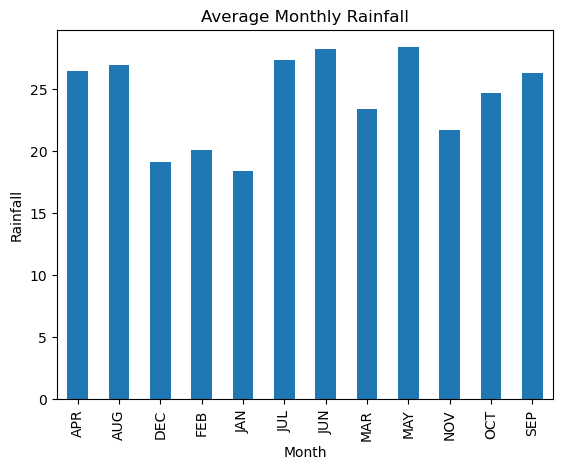

In [17]:
import matplotlib.pyplot as plt

data_long.groupby('Month')['Rainfall'].mean().plot(kind='bar')
plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

In [18]:
plt.figure(figsize=(12,8))


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [21]:
import pandas as pd
import calendar

data = pd.read_csv("Weather.csv")
data = data.drop(columns=['Unnamed: 0'])

# Convert to long format
data_long = data.melt(id_vars=['YEAR'], 
                      var_name='month_name', 
                      value_name='Rainfall')

# Create Rainy / Dry classification
data_long['Rainy'] = data_long['Rainfall'] > 0

# Count days (yaha hum assume kar rahe hain har row = 1 unit)
monthly = data_long.groupby(['month_name', 'Rainy']).size().reset_index(name='Days')

# Month order fix
month_order = list(calendar.month_abbr)[1:]
monthly['month_name'] = pd.Categorical(monthly['month_name'], categories=month_order, ordered=True)

monthly = monthly.sort_values(['month_name', 'Rainy'])

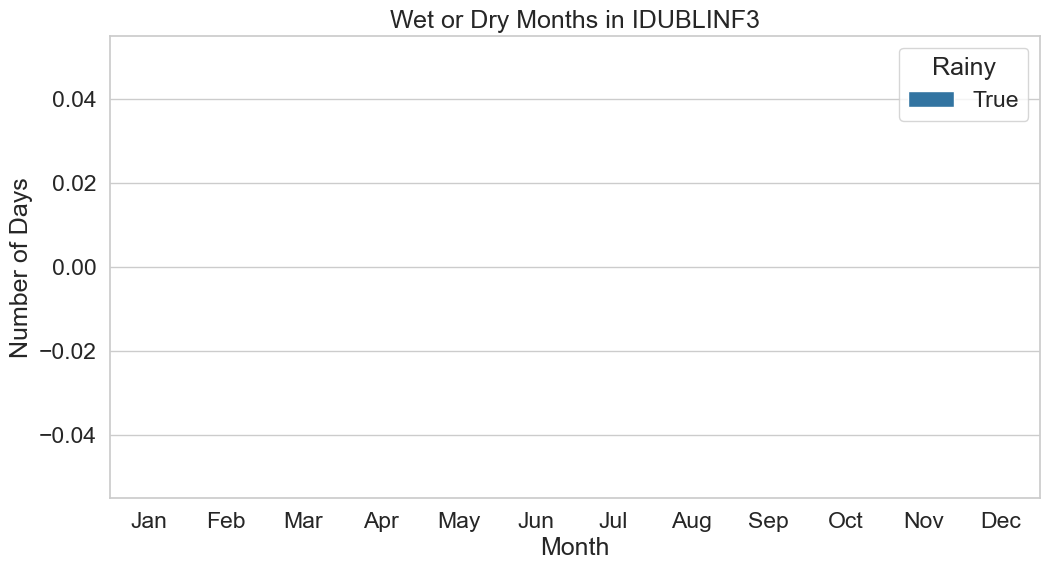

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)

plt.figure(figsize=(12,6))

sns.barplot(
    x="month_name",
    y="Days",
    hue="Rainy",
    data=monthly
)

plt.xlabel("Month")
plt.ylabel("Number of Days")
plt.title(f"Wet or Dry Months in {station}")

plt.show()

In [25]:
import pandas as pd

data = pd.read_csv("Weather.csv")
data = data.drop(columns=['Unnamed: 0'])

# Convert to long format
data_long = data.melt(id_vars=['YEAR'], 
                      var_name='month', 
                      value_name='rainfall')

# FIX: manual mapping (best way)
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4,
    'MAY': 5, 'JUN': 6, 'JUL': 7, 'AUG': 8,
    'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}

data_long['month_num'] = data_long['month'].map(month_map)

# 🔍 Debug check
print(data_long[data_long['month_num'].isna()])

Empty DataFrame
Columns: [YEAR, month, rainfall, month_num]
Index: []


In [26]:
data_long = data_long.dropna(subset=['month_num'])

data_long['date'] = pd.to_datetime(
    data_long['YEAR'].astype(int).astype(str) + '-' +
    data_long['month_num'].astype(int).astype(str) + '-01'
)

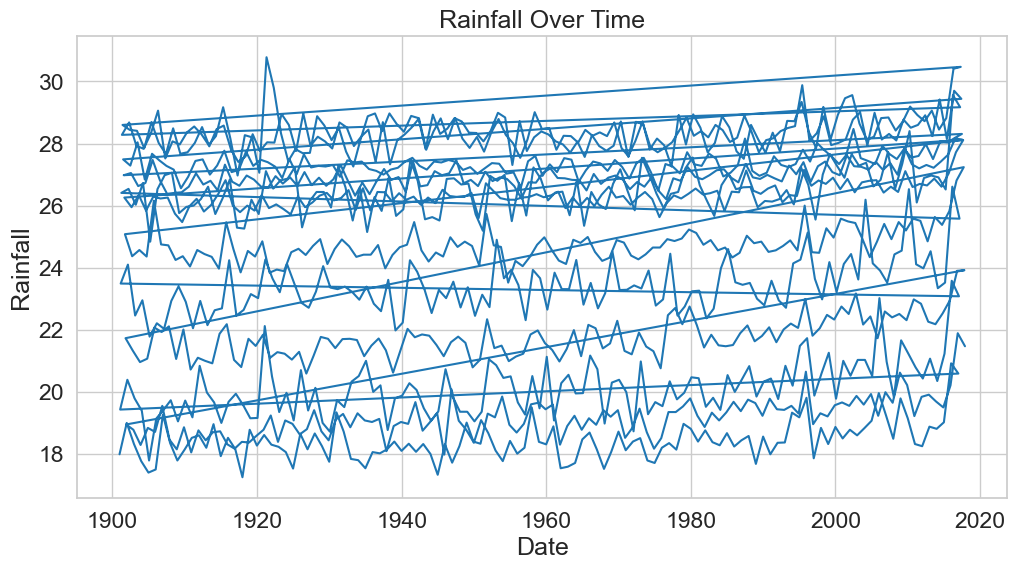

In [29]:
import matplotlib.pyplot as plt

data_long.reset_index(inplace=True)

plt.figure(figsize=(12,6))
plt.plot(data_long['date'], data_long['rainfall'])

plt.title("Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rainfall")

plt.show()

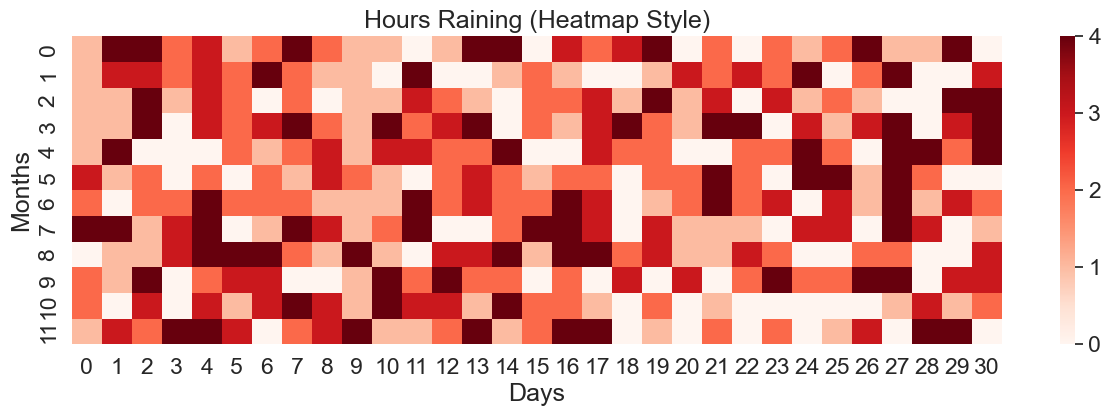

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Fake daily rainfall data (for demo)
data = np.random.randint(0, 5, size=(12, 31))  # 12 months × 31 days

plt.figure(figsize=(15,4))
sns.heatmap(data, cmap="Reds", cbar=True)

plt.title("Hours Raining (Heatmap Style)")
plt.xlabel("Days")
plt.ylabel("Months")

# ✅ Save for printing
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

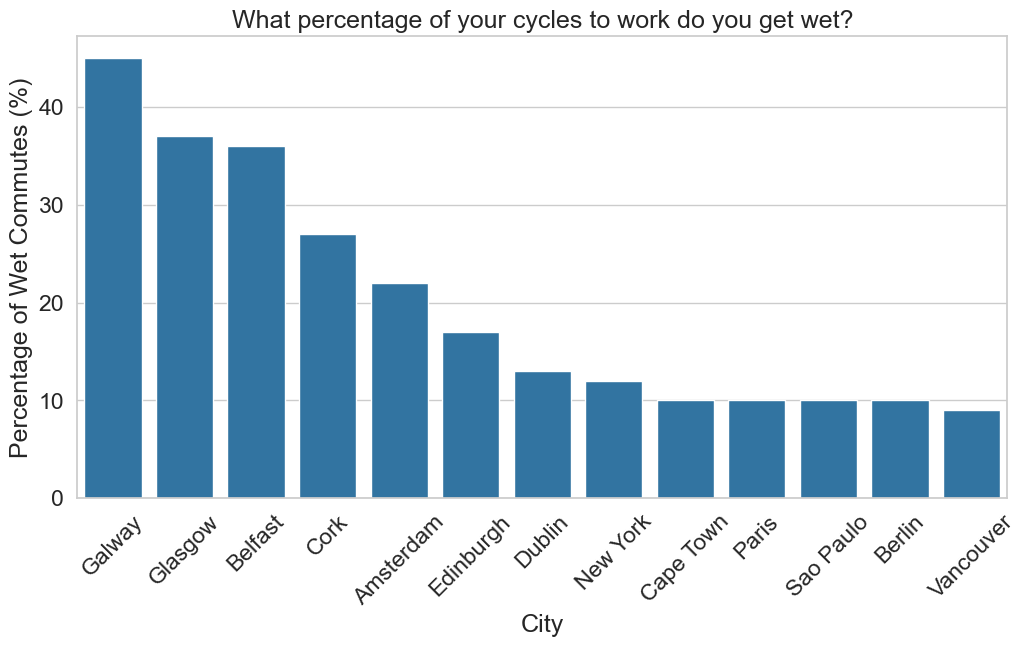

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data (tum apne data se replace kar sakte ho)
cities = ["Galway","Glasgow","Belfast","Cork","Amsterdam","Edinburgh",
          "Dublin","New York","Cape Town","Paris","Sao Paulo","Berlin","Vancouver"]

percent = [45, 37, 36, 27, 22, 17, 13, 12, 10, 10, 10, 10, 9]

plt.figure(figsize=(12,6))
sns.barplot(x=cities, y=percent)

plt.xticks(rotation=45)
plt.ylabel("Percentage of Wet Commutes (%)")
plt.xlabel("City")
plt.title("What percentage of your cycles to work do you get wet?")

# ✅ Save for printing
plt.savefig("bar_chart.png", dpi=300, bbox_inches='tight')

plt.show()